## Dependencies

In [1]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("./bank-issues-042022/train.csv")
df_test = pd.read_csv("./bank-issues-042022/test.csv")

Поля данных:
- **client_id** — Уникальный идентификатор клиента
- **gender** — Пол
- **age** — Возраст (в годах)
- **marital_status** — Семейное положение.
    Возможные значения:
    - UNM : Холост/не замужем
    - DIV : Резведен (а)
    - MAR : Женат/замужем
    - WID : Вдовец, вдова
    - CIV : Гражданский брак
- **job_position** — Работа.
    Возможные значения:
    - SPC : Неруководящий сотрудник - специалист
    - DIR : Руководитель организации
    - HSK : Домохозяйка
    - WOI : Работает на ИП
    - WRK : Неруководящий сотрудник - рабочий
    - ATP : Неруководящий сотрудник - обслуживающий персонал
    - WRP : Работающий пенсионер
    - UMN : Руководитель подразделения
    - NOR : Не работает
    - NS : Пенсионер
    - BIS : Собственный бизнес
    - INP : Индивидуальный предприниматель
- **credit_sum** — Сумма кредита
- **credit_month** — Срок кредитования в месяцах
- **tariff_id** — Номер предлагаемого тарифа
- **education** — Тип образования.
    Возможные знаяения:
    - SCH : Начальное, среднее
    - PGR : Второе высшее
    - GRD : Высшее
    - UGR : Неполное высшее
    - ACD : Ученая степень
- **living_region** — Регион проживания
- **monthly_income** — Зарплата в месяц
- **credit_count** — Количество кредитов у клиента
- **overdue_credit_count** — Количество просроченных кредитов клиента
- **open_account_flag** — Целевая переменная -- выберет клиент наш банк или нет

## EDA

In [3]:
df_train.shape, df_test.shape

((119518, 15), (51222, 14))

In [4]:
df_train.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,tariff_id,score_shk,education,living_region,monthly_income,credit_count,overdue_credit_count,open_account_flg
0,1,M,25,UNM,SPC,26389.0,10,1.32,0.584105,SCH,ОБЛ КУРСКАЯ,35000.0,2.0,0.0,1
1,2,F,37,MAR,SPC,19588.0,12,1.43,0.718935,SCH,РЕСПУБЛИКА ТАТАРСТАН,15000.0,0.0,0.0,1
2,3,F,28,UNM,SPC,53669.0,18,1.10,0.586015,GRD,МОСКВА Г,70000.0,4.0,0.0,1
3,4,M,34,MAR,SPC,26349.0,10,1.43,0.655703,SCH,СВЕРДЛОВСКАЯ ОБЛАСТЬ,42500.0,4.0,0.0,0
4,5,F,43,MAR,UMN,11589.0,10,1.10,0.271893,GRD,РЯЗАНСКАЯ ОБЛАСТЬ,20000.0,3.0,0.0,0


In [5]:
df_train.dtypes

client_id                 int64
gender                   object
age                       int64
marital_status           object
job_position             object
credit_sum              float64
credit_month              int64
tariff_id               float64
score_shk               float64
education                object
living_region            object
monthly_income          float64
credit_count            float64
overdue_credit_count    float64
open_account_flg          int64
dtype: object

In [6]:
df_test.dtypes

client_id                 int64
gender                   object
age                       int64
marital_status           object
job_position             object
credit_sum              float64
credit_month              int64
tariff_id               float64
score_shk               float64
education                object
living_region            object
monthly_income          float64
credit_count            float64
overdue_credit_count    float64
dtype: object

In [7]:
df_train.isna().sum()

client_id                  0
gender                     0
age                        0
marital_status             0
job_position               0
credit_sum                 0
credit_month               0
tariff_id                  0
score_shk                  0
education                  0
living_region            133
monthly_income             0
credit_count            6486
overdue_credit_count    6486
open_account_flg           0
dtype: int64

In [8]:
df_test.isna().sum()

client_id                  0
gender                     0
age                        0
marital_status             0
job_position               0
credit_sum                 0
credit_month               0
tariff_id                  0
score_shk                  0
education                  0
living_region             59
monthly_income             1
credit_count            2743
overdue_credit_count    2743
dtype: int64

In [9]:
def num_eda(column):
    print(f"Train {column}")
    print(df_train[column].describe())

    print(f"Test {column}")
    print(df_test[column].describe())

    plt.figure(figsize=(3, 3))
    sns.boxplot(df_train[column])
    plt.title(f"Train {column}")
    plt.show()

    plt.figure(figsize=(3, 3))
    sns.boxplot(df_test[column])
    plt.title(f"Test {column}")
    plt.show()

    plt.figure(figsize=(3, 3))
    sns.boxplot(df_train[column])
    plt.title(f"Train {column}")
    plt.show()

    plt.figure(figsize=(3, 3))
    sns.boxplot(df_test[column])
    plt.title(f"Test {column}")
    plt.show()

    # plt.figure(figsize=(3, 3))
    sns.histplot(df_train[column])
    plt.title(f"Train {column}")
    plt.show()

    # plt.figure(figsize=(3, 3))
    sns.histplot(df_test[column])
    plt.title(f"Test {column}")
    plt.show()

    sns.boxplot(df_train, x=column, hue='open_account_flg')
    plt.title(f"Train {column} hue open_account_flg")
    plt.show()

    sns.histplot(df_train, x=column, hue='open_account_flg')
    plt.title(f"Train {column} hue open_account_flg")
    plt.show()

In [10]:
def cat_eda(column):
    plt.title(f"Train {column}")
    ax = sns.countplot(data=df_train, x=column, stat='percent')
    ax.bar_label(ax.containers[0])
    plt.show()

    plt.title(f"Test {column}")
    ax = sns.countplot(data=df_test, x=column, stat='percent')
    ax.bar_label(ax.containers[0])
    plt.show()

    plt.title(f"Train {column} hue open_account_flg")
    ax = sns.countplot(df_train, x=column, hue='open_account_flg', stat='percent')
    ax.bar_label(ax.containers[0])
    plt.show()

### Numeric

#### age

Train age
count    119518.000000
mean         36.508451
std          10.550192
min          18.000000
25%          28.000000
50%          34.000000
75%          43.000000
max          71.000000
Name: age, dtype: float64
Test age
count    51222.000000
mean        36.470423
std         10.536002
min         18.000000
25%         28.000000
50%         34.000000
75%         43.000000
max         71.000000
Name: age, dtype: float64


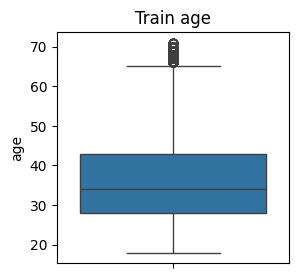

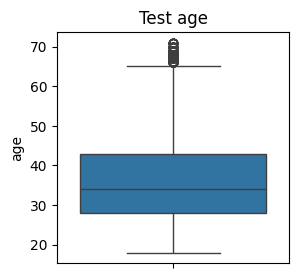

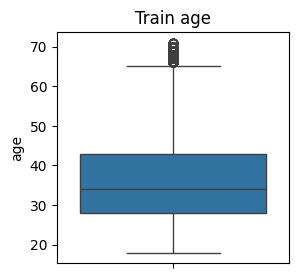

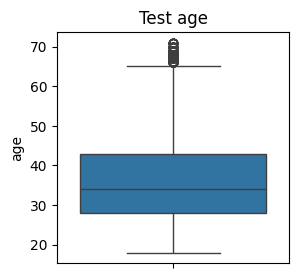

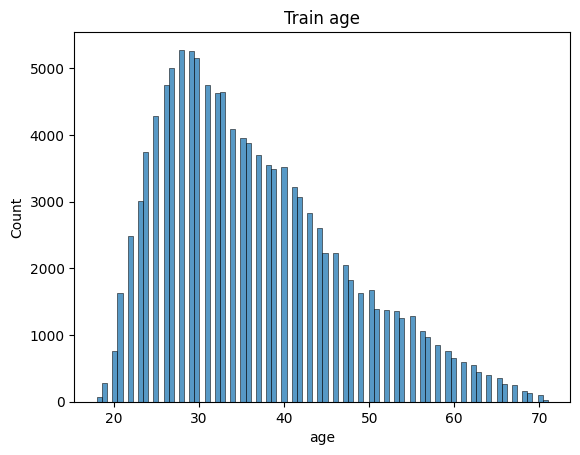

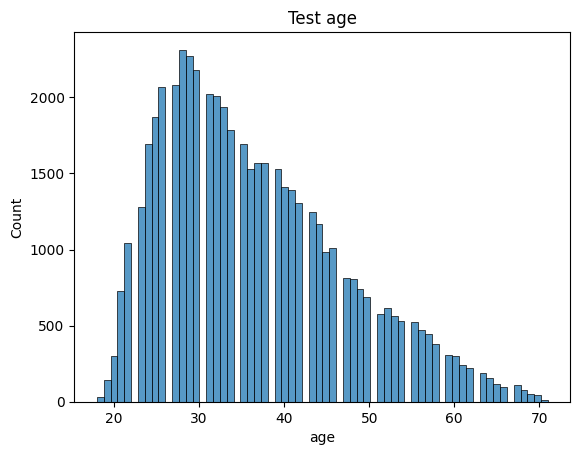

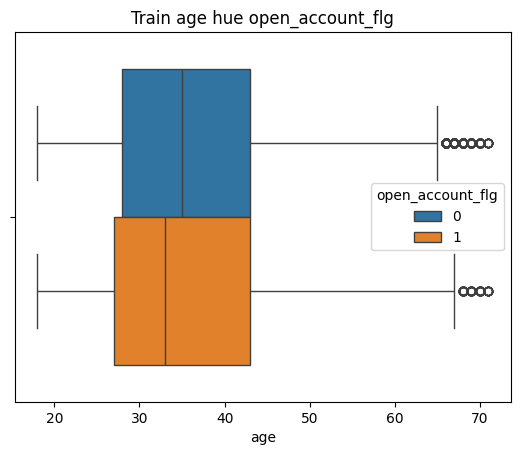

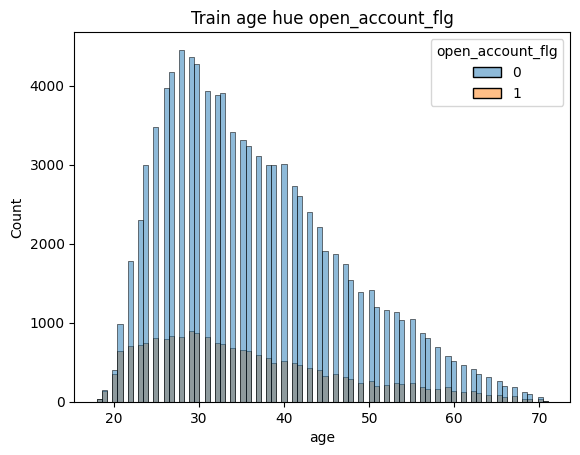

In [11]:
num_eda('age')

#### credit_sum

Train credit_sum
count    119518.000000
mean      26095.265071
std       16266.110505
min        2736.000000
25%       14898.917500
50%       21244.665000
75%       32068.000000
max      200000.000000
Name: credit_sum, dtype: float64
Test credit_sum
count     51222.000000
mean      26095.757860
std       16162.048182
min        3000.000000
25%       14922.500000
50%       21206.900000
75%       32068.000000
max      200000.000000
Name: credit_sum, dtype: float64


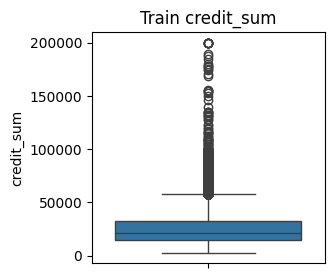

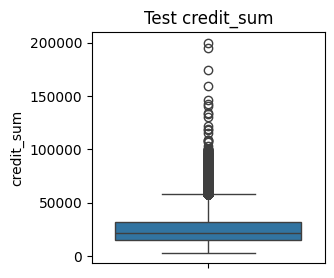

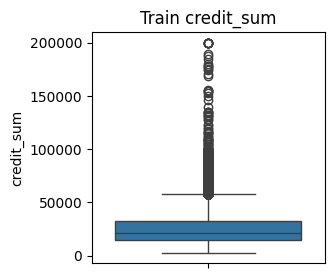

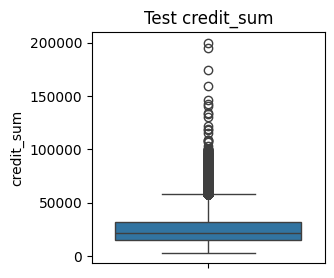

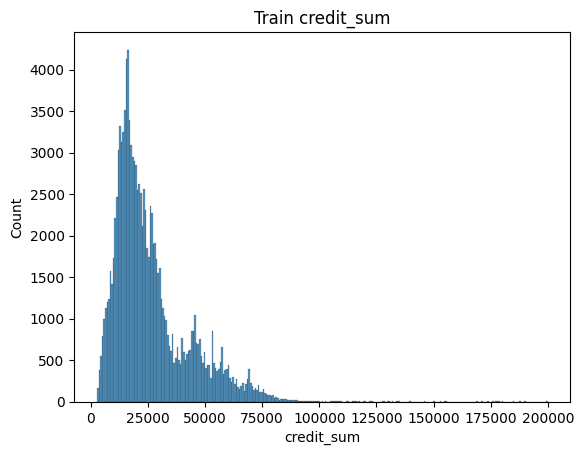

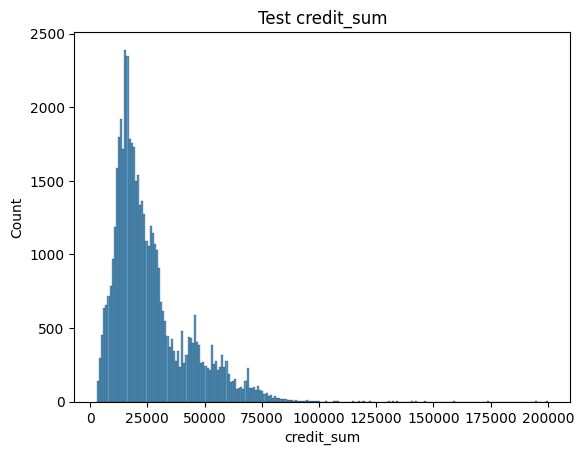

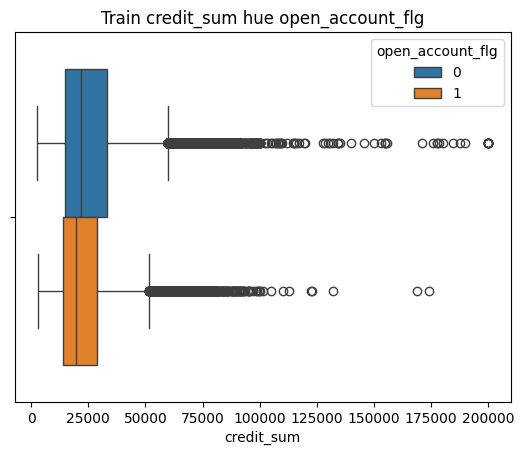

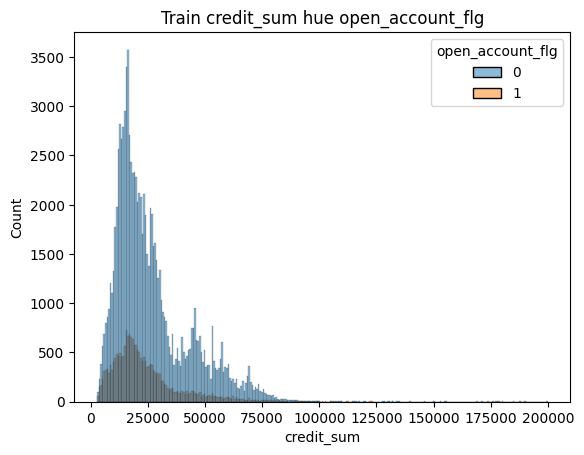

In [12]:
num_eda('credit_sum')

#### credit_month

Train credit_month
count    119518.000000
mean         10.979702
std           3.537339
min           3.000000
25%          10.000000
50%          10.000000
75%          12.000000
max          36.000000
Name: credit_month, dtype: float64
Test credit_month
count    51222.000000
mean        10.983113
std          3.534976
min          3.000000
25%         10.000000
50%         10.000000
75%         12.000000
max         36.000000
Name: credit_month, dtype: float64


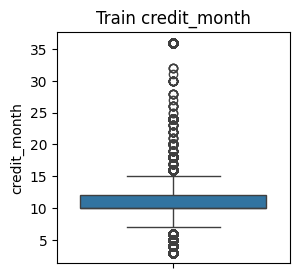

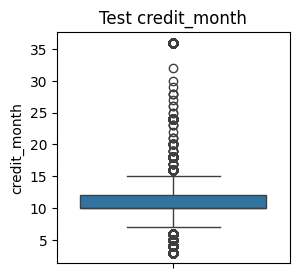

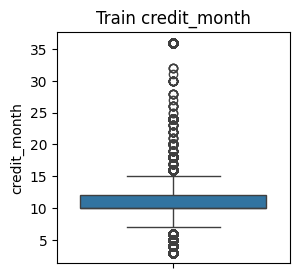

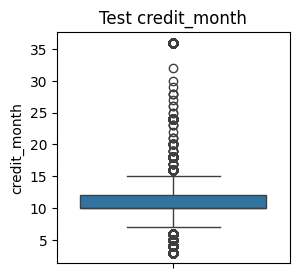

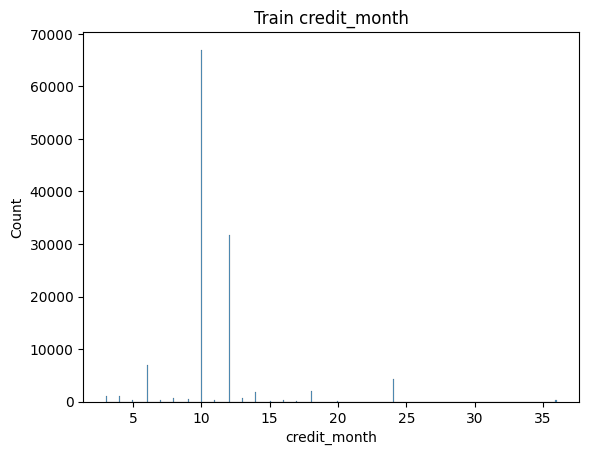

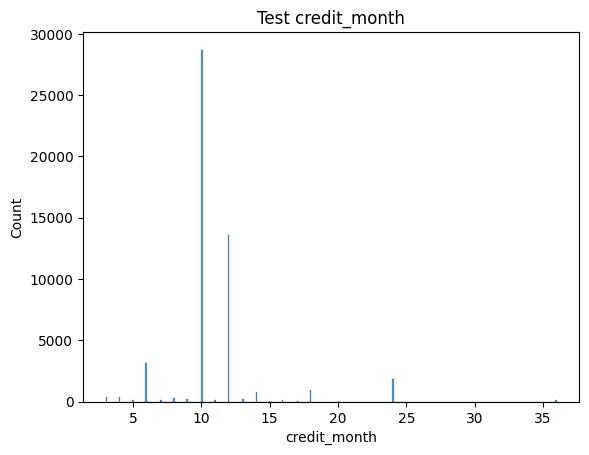

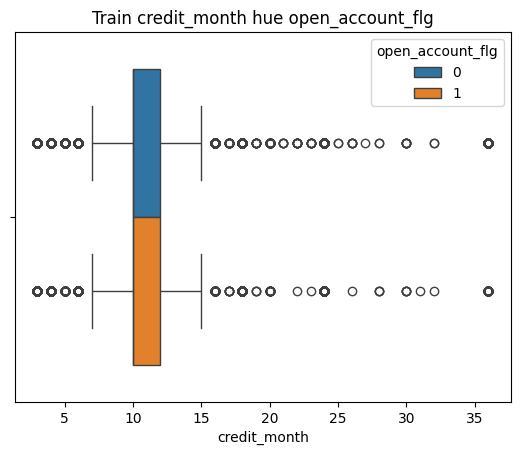

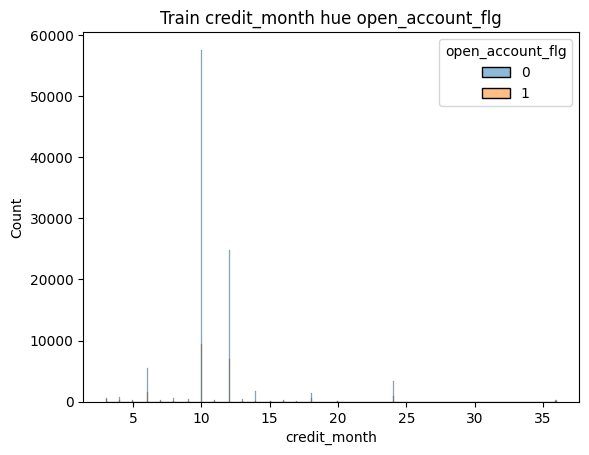

In [13]:
num_eda('credit_month')

#### score_shk

Train score_shk
count    119518.000000
mean          0.470053
std           0.124181
min           0.000000
25%           0.380353
50%           0.462000
75%           0.552855
max           1.128291
Name: score_shk, dtype: float64
Test score_shk
count    51222.000000
mean         0.468121
std          0.124459
min          0.071819
25%          0.377390
50%          0.460234
75%          0.551538
max          0.974599
Name: score_shk, dtype: float64


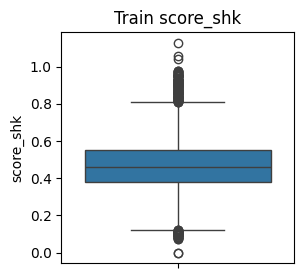

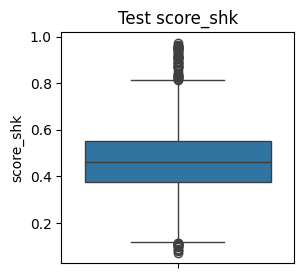

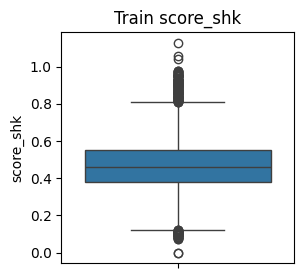

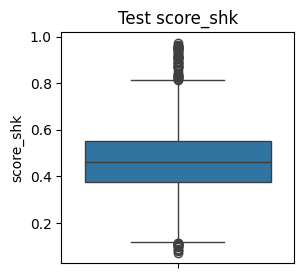

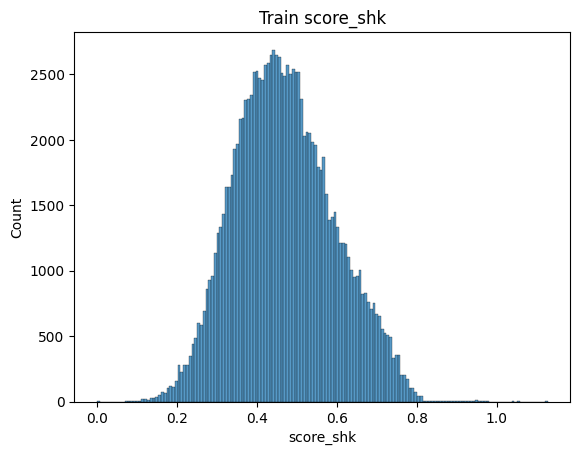

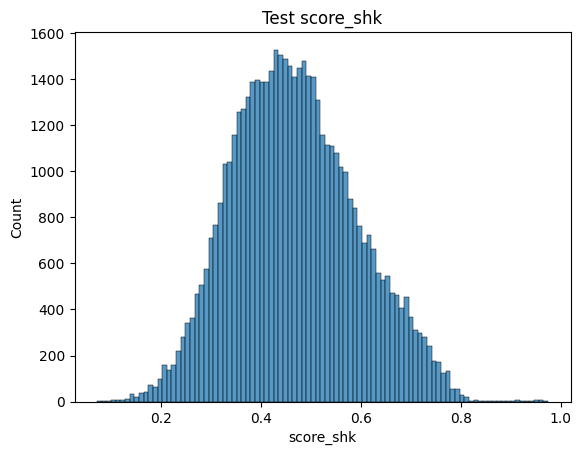

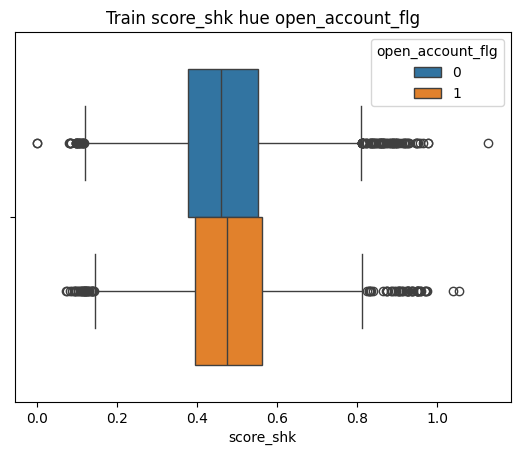

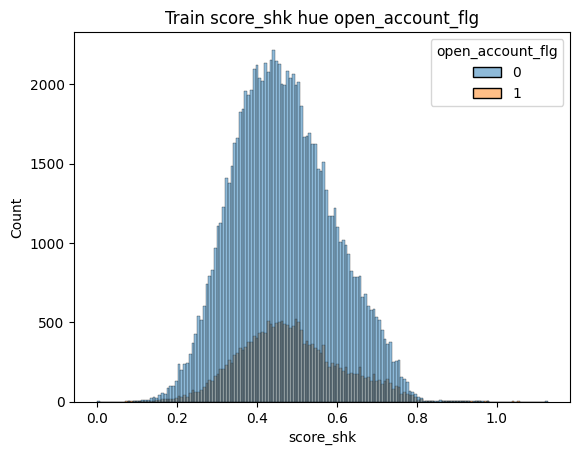

In [14]:
num_eda("score_shk")

#### monthly_income

Train monthly_income
count    119518.000000
mean      40101.980664
std       25099.432178
min        5600.000000
25%       25000.000000
50%       35000.000000
75%       50000.000000
max      800000.000000
Name: monthly_income, dtype: float64
Test monthly_income
count     51221.000000
mean      40224.871049
std       24915.244559
min        5000.000000
25%       25000.000000
50%       35000.000000
75%       50000.000000
max      950000.000000
Name: monthly_income, dtype: float64


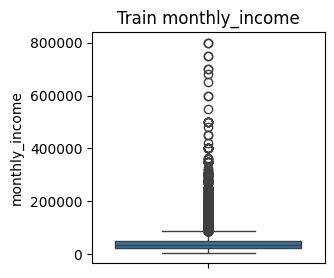

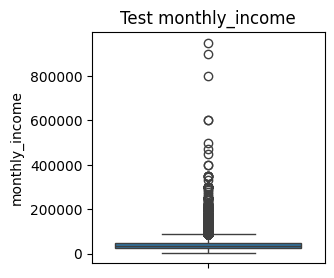

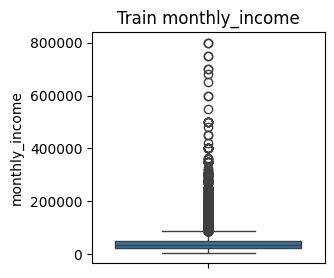

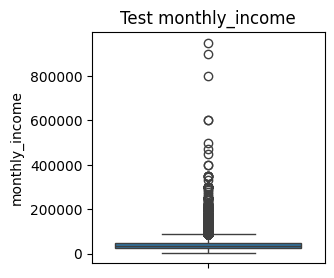

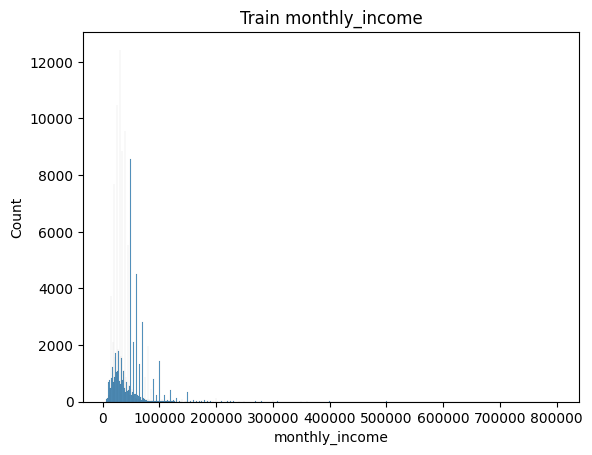

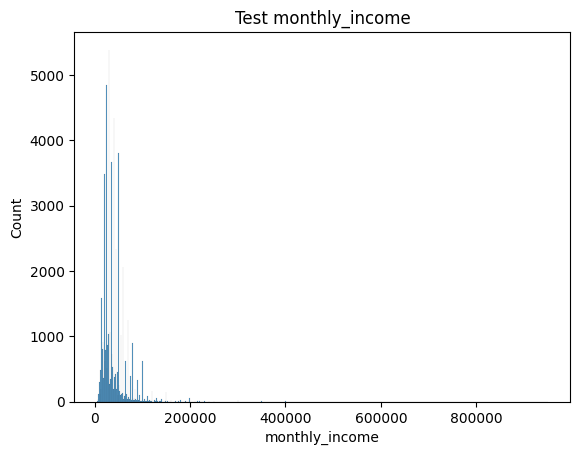

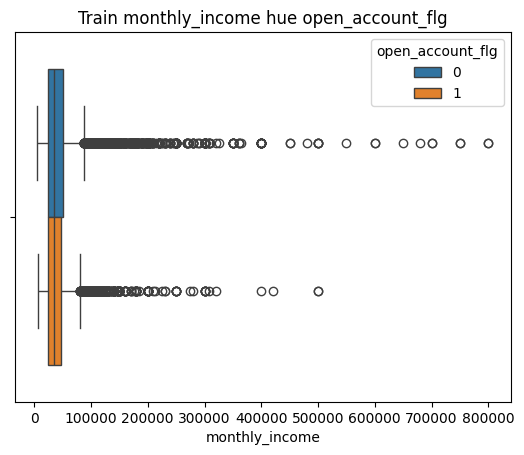

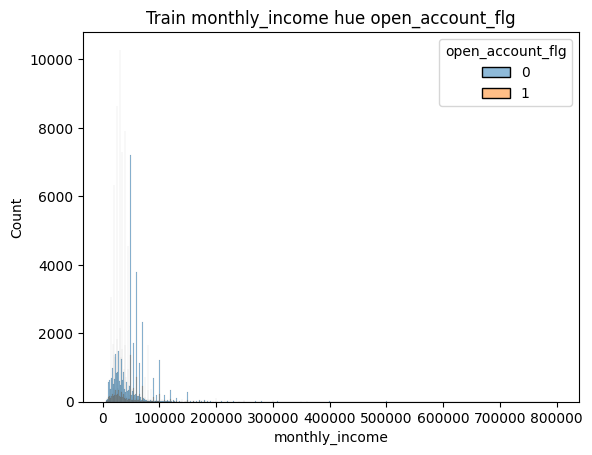

In [15]:
num_eda('monthly_income')

#### credit_count (has NA)

Train credit_count
count    113032.000000
mean          2.102210
std           1.777117
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          19.000000
Name: credit_count, dtype: float64
Test credit_count
count    48479.000000
mean         2.119351
std          1.777134
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         21.000000
Name: credit_count, dtype: float64


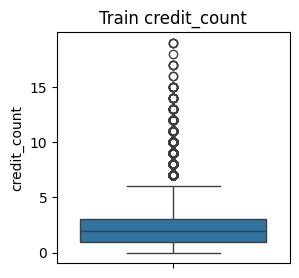

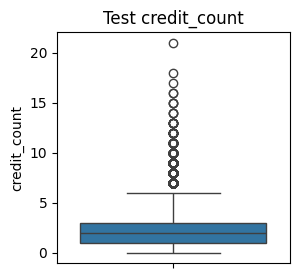

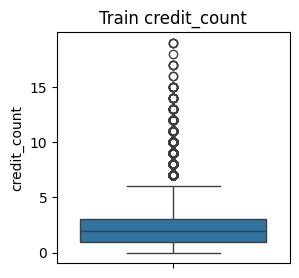

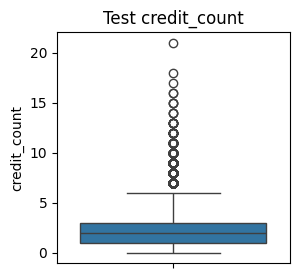

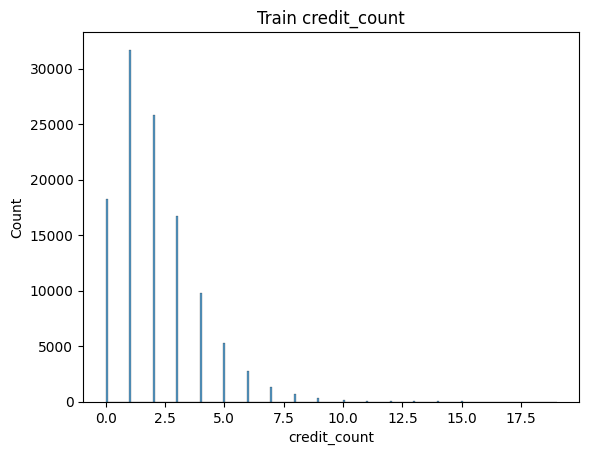

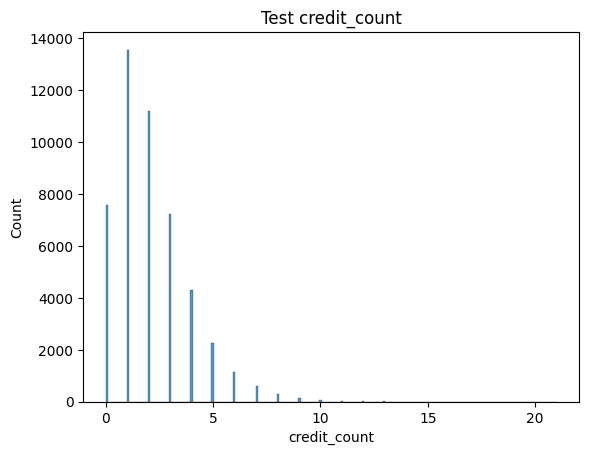

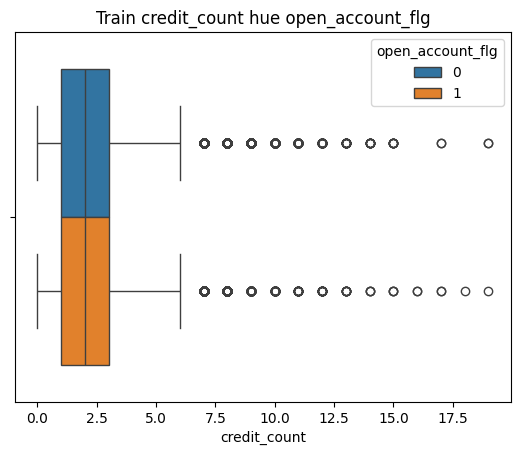

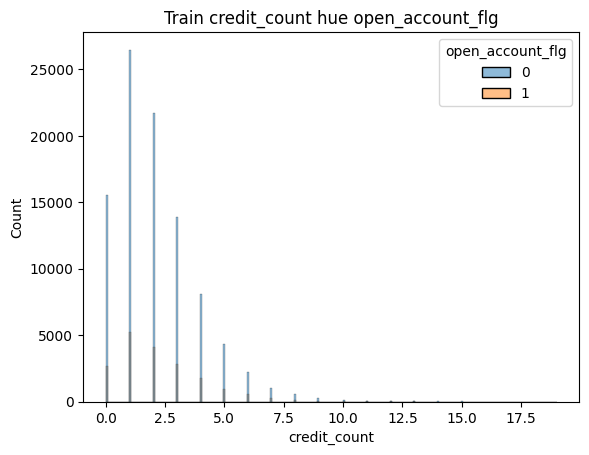

In [16]:
num_eda('credit_count')

#### overdue_credit_count (has NA)

Train overdue_credit_count
count    113032.000000
mean          0.046571
std           0.212725
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: overdue_credit_count, dtype: float64
Test overdue_credit_count
count    48479.000000
mean         0.044906
std          0.208786
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: overdue_credit_count, dtype: float64


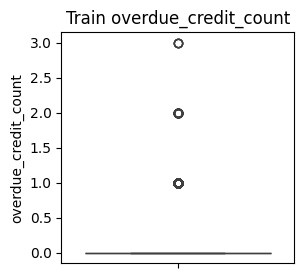

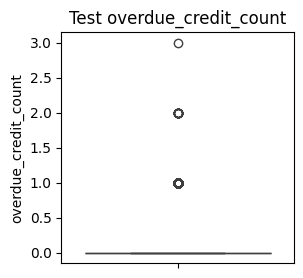

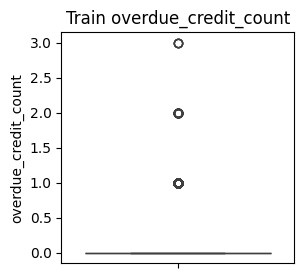

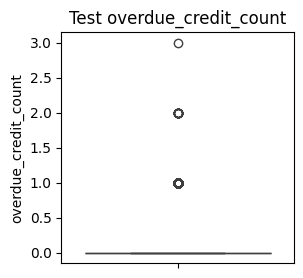

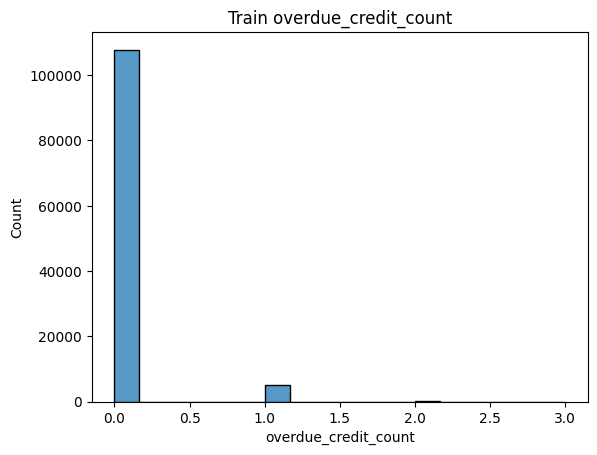

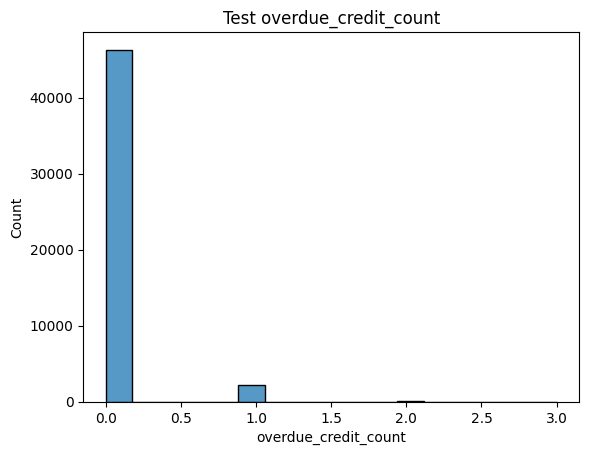

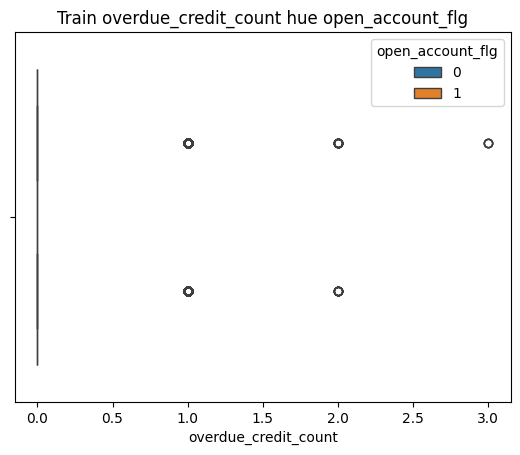

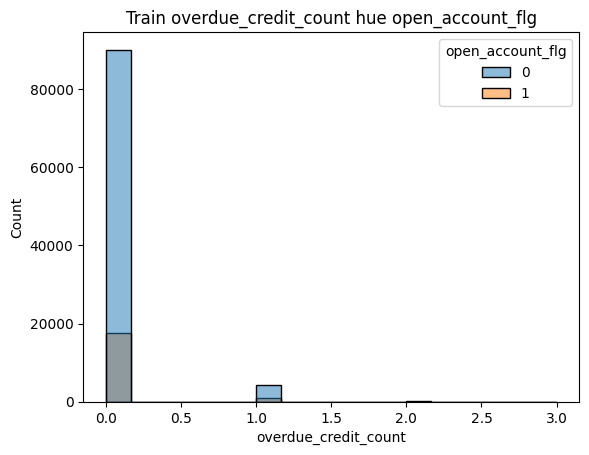

In [17]:
num_eda('overdue_credit_count')

### Categorical

#### gender

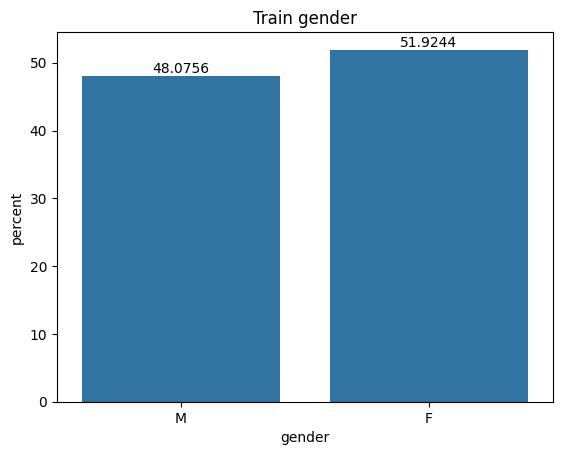

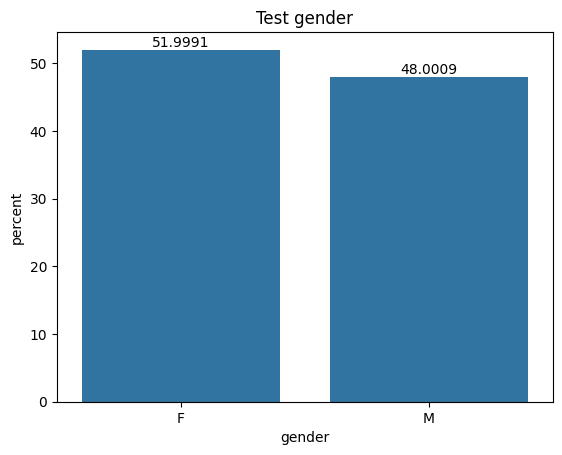

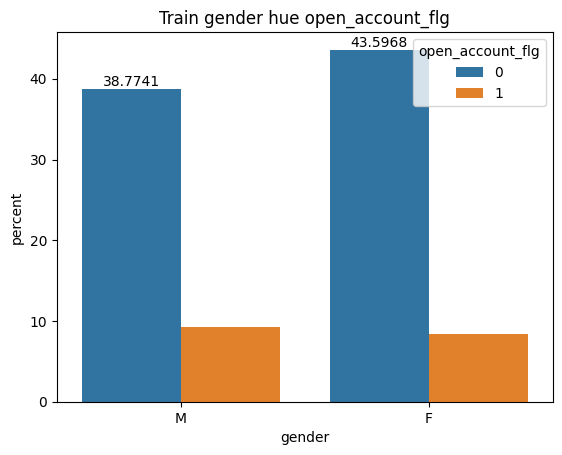

In [20]:
cat_eda('gender')

#### marital_status

In [21]:
eda_cat('marital_status')

NameError: name 'eda_cat' is not defined